## Class 12 homework - Correlation, correlation matrix, correlation heatmap

Correlation coefficients are an essential tool for understanding how different pieces of data are related. There are many different versions of correlation coefficients, some linear and some non-linear or adaptable to different kinds of data.

Today we'll focus on the "Pearson correlation coefficient", or linear correlation, often abbreviated as $R$.

One use for the linear correlation is that, in a simple linear regression, $R^2$ is the proportion of variance explained.

### Reminder on definitions

Reminder, the definition of correlation coefficient is:

$ Correlation(X, Y ) = \frac{Covariance(X, Y)}{\sqrt( Variance(X) Variance(Y) )} $

Correlation takes values between -1 and -1; no correlation gives a value of zero.

Another reminder:

$ Covariance(X, Y) = \frac{1}{n} \sum_{i=1}^{n} (X_i - Mean(X) ) (Y_i - Mean(Y) ) $

Look this up if you need to revise what it means.

**Challenge: could you write a Python function that calculates the correlation coefficient using sums and squaring things?**

In [ ]:
# no answer given - this is a challenge for the curious.

Here we'll learn about the relation of correlations to scatter plots, and introduce the correlation heatmap as a tool to visualise relationships between many variables at once even when a pairplot is just too overwhelming to be useful.

## Load modules

Here we will import the ```scipy.stats.pearsonr```, a function that calculates the correlation coefficient (a.k.a. pearson's R) of two numerical datatypes

Later we will also use the pandas dataframe method / function, ```.corr```.

In [1]:
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr

## Load data

Let's start with the abalone dataset that was also used in class 12

In [2]:
df_abalone = pd.read_csv("./abalone.csv")

In [3]:
df_abalone

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


First, let's just choose 2 variables: Length and Diameter.

Plot a scatter plot using ```sns.scatterplot```, and then calculate the correlation coefficient using ```pearsonr```

<Axes: xlabel='Length', ylabel='Diameter'>

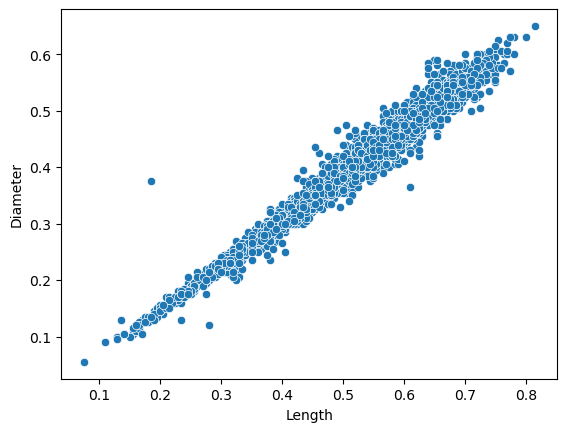

In [4]:
sns.scatterplot( data = df_abalone, x = "Length", y = "Diameter")

In [5]:
pearsonr(x = df_abalone["Length"], y = df_abalone["Diameter"])

PearsonRResult(statistic=0.9868115846024931, pvalue=0.0)

This is clearly a high correlation.

## Can I guess the correlation just by looking at a scatter plot?

Why yes you can! Try Guess The Correlation game, at https://www.guessthecorrelation.com

**TIP: For actual data analysis, always calculate the correlation as well as looking at the data and making a visual estimate.**

## Correlations between many pairs of variables

What if we want to compare all pairs of variables?

Plot a pairplot.

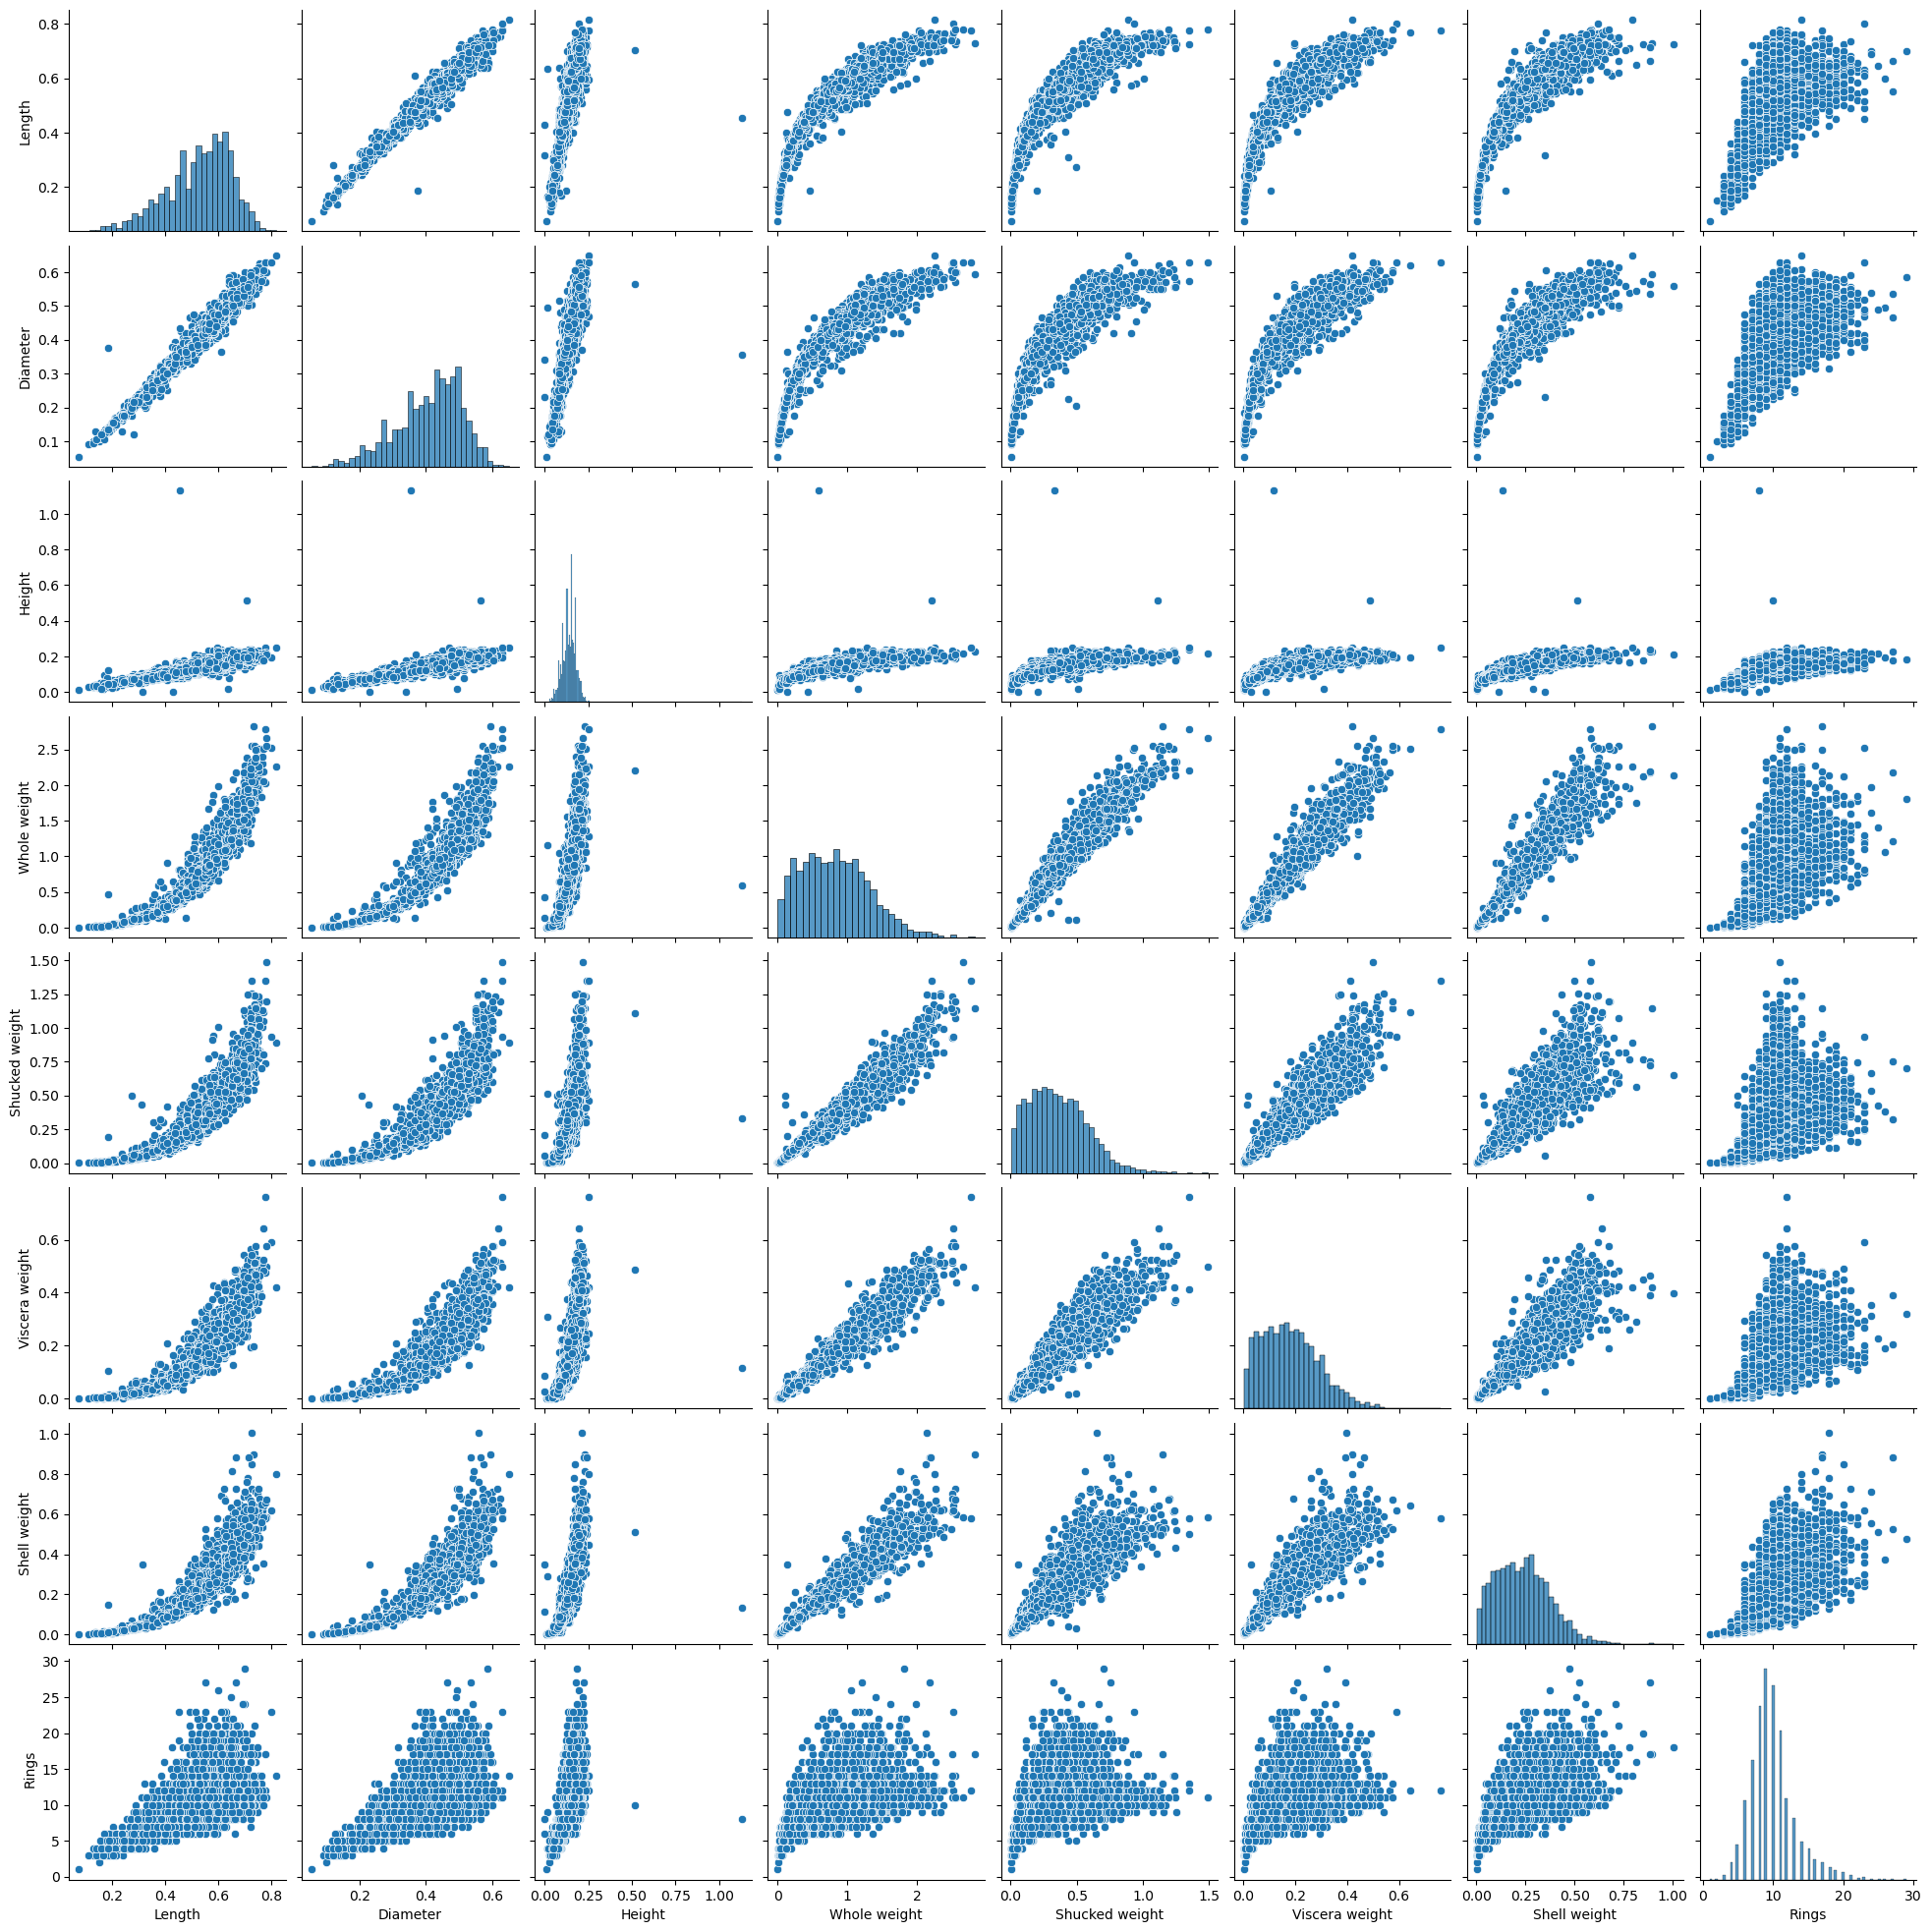

In [6]:
sns.pairplot(df_abalone)

Each plot in the pair plot compares only 2 of the columns in a data frame - well, at least for the numerical columns.

The correlation matrix is a bit like the pair plot, only instead of showing a plot, it shows a number, which is the correlation coefficient.

Calculate the correlation matrix by applying ```.corr()``` to ```df_abalone```.
Being precise, you have to choose only numerical columns to calculate correlations, or you could use the `numeric

In [7]:
# example using iloc to remove column zero (Sex) before calculating
df_abalone.iloc[:, 1:].corr()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
Length,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720
Diameter,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467
Whole weight,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390
Shucked weight,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884
Viscera weight,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819
Shell weight,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574
Rings,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000


In [8]:
# example using numeric_only
df_abalone.corr(numeric_only=True)

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
Length,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720
Diameter,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467
Whole weight,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390
Shucked weight,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884
Viscera weight,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819
Shell weight,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574
Rings,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000


Note some things here:

- The correlation matrix entry on the diagonals are 1, because everything is perfectly correlated with itself.
- The correlation matrix is symmetrical across the diagonal
- The correlation of Length and Diameter is exactly what we calculated before
- Irritatingly, the order of rows in the correlation matrix is opposite to the order in the pairplot.
- Compare the correlation coefficient values in the matrix with the plots in the pairplot

## Introducing the correlation heatmap

How can we visualize these data so that we are not just looking at tables of numbers?

The correlation heatmap does this.

First, assign the correlation matrix to a variable. You might call it abalone_corr. Then plot this heatmap using ```sns.heatmap```

<Axes: >

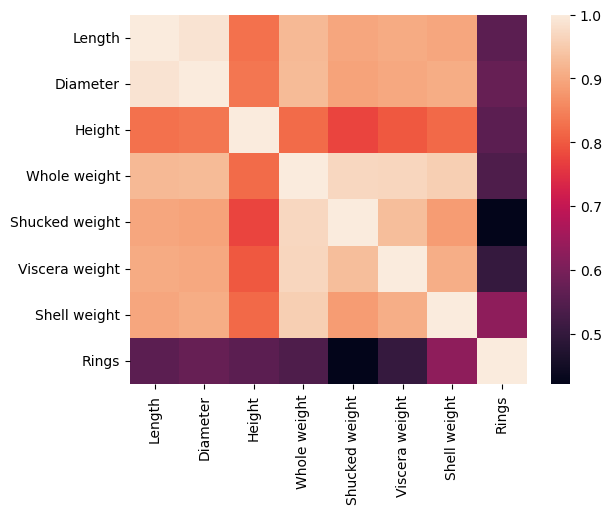

In [9]:
abalone_corr = df_abalone.corr(numeric_only=True)

sns.heatmap(abalone_corr)

Comparing this to the correlation matrix, with the default colour palette high correlations are in off-white and low correlations red.

Next, try changing the colour palette to emphasize the high correlations in a darker colour. Take suggestions from https://seaborn.pydata.org/tutorial/color_palettes.html, and use the ```cmap``` argument to ```sns.heatmap()```. You might try a diverging colour palette, that would make negative correlations stand out from positive correlations.

Also set the centre/center of the colour map to zero, to de-emphasize zero correlations.

<Axes: >

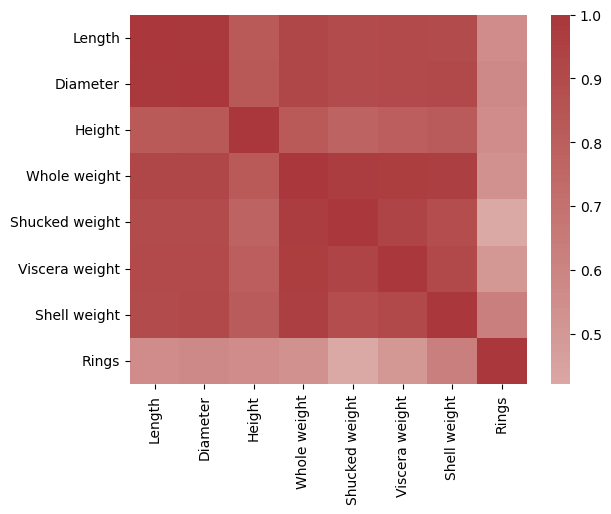

In [10]:
sns.heatmap(abalone_corr, center = 0, cmap = sns.color_palette("vlag", as_cmap=True))

This alternative view emphasizes that everything in this particular dataset is pretty well correlated.

Many variables in a dataset being well-correlated indicates that the dataset has underlying low dimensionality - this idea will be explored much more in class next week.


## Plot correlations for another dataset

Correlation heatmaps are very useful tools for exploring multivariate data. You are likely to use them in the group project.

Try applying these to the ```penguins.csv``` datasets from the Datasets folder.

It will be useful to compare to pairplots, and to see how correlation heatmaps can summarise information - they tell you less than a pairplot, but can make overall patterns easier to see.

In [11]:
df_penguins = pd.read_csv("../Datasets/penguins.csv")

df_penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


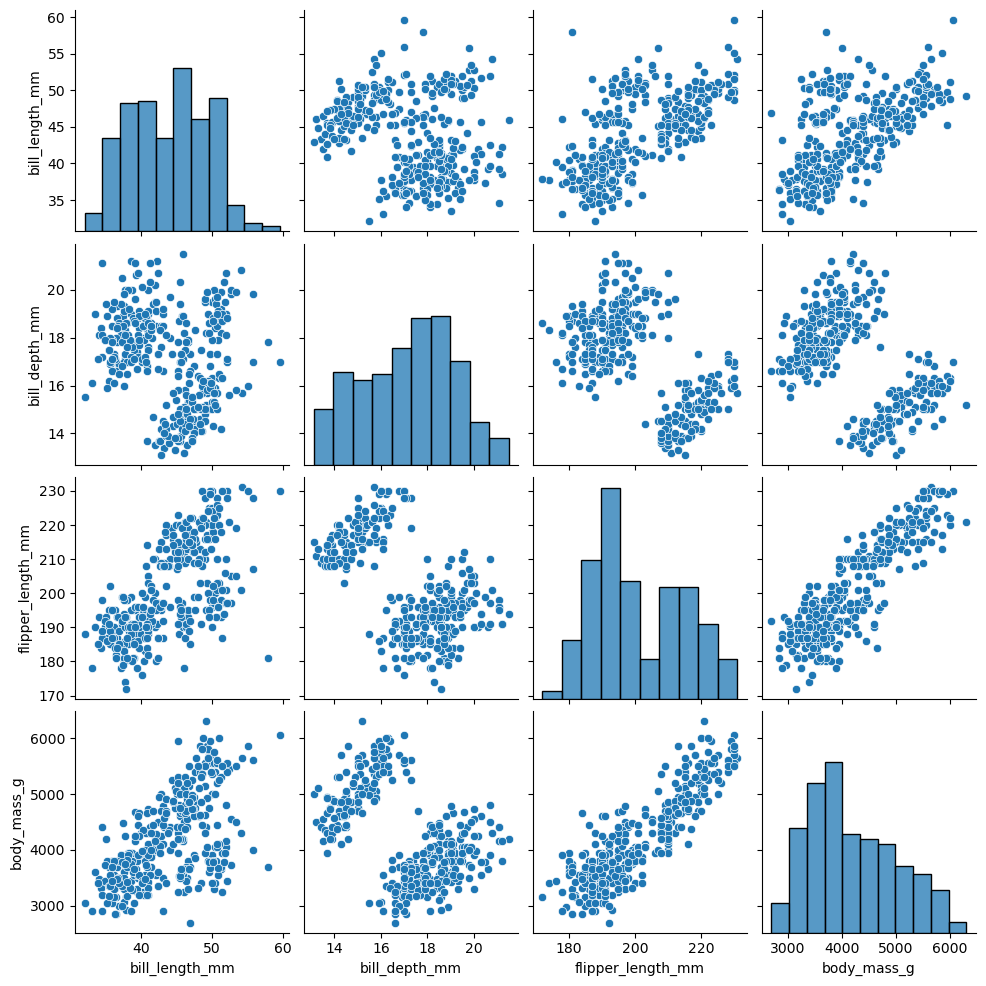

In [12]:
sns.pairplot(df_penguins)

<Axes: >

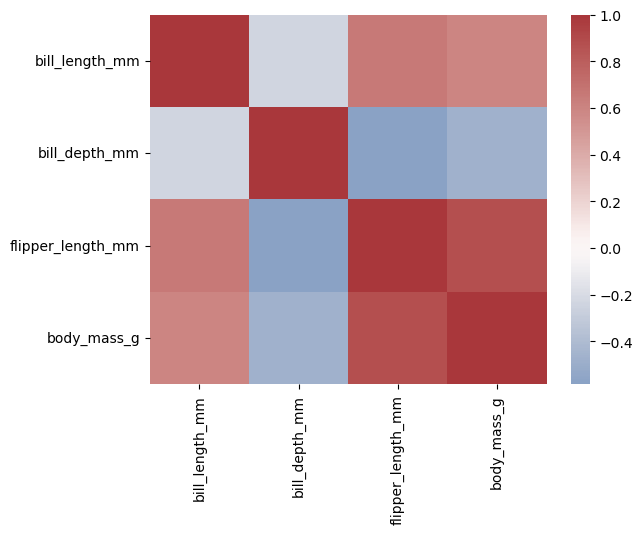

In [13]:
penguins_corr = df_penguins.corr(numeric_only=True)

sns.heatmap(penguins_corr, center = 0, cmap = sns.color_palette("vlag", as_cmap=True))

Think about what this means, and compare it to the figures.

In the penguins case, the correlations within-species are different from the correlations across multiple species. This phenomenon, where "a trend appears in several groups of data but disappears or reverses when the groups are combined," is called [Simpson's paradox](https://en.wikipedia.org/wiki/Simpson%27s_paradox).

To avoid this paradox, first plot the pairplot coloured by species.

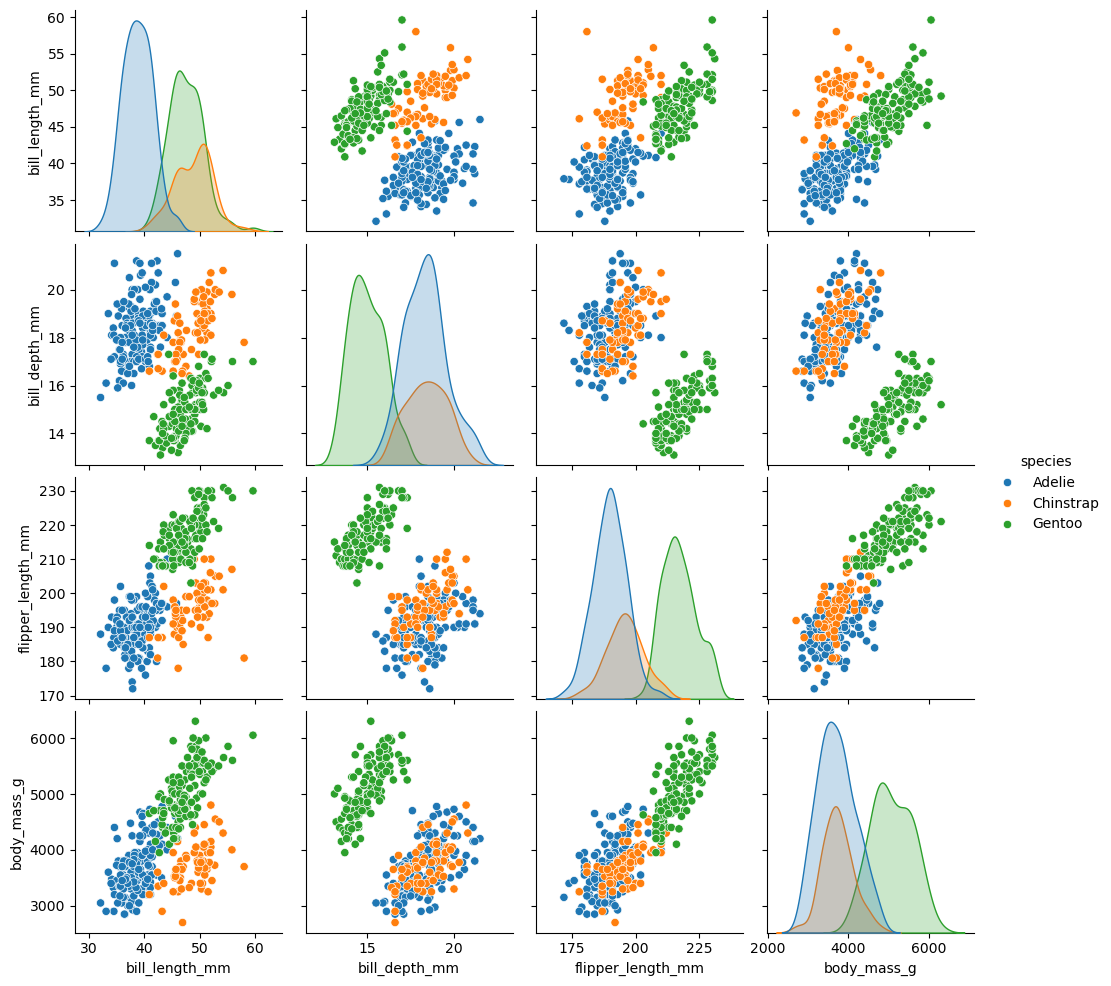

In [14]:
sns.pairplot(df_penguins, hue = "species")

Then plot the correlation heatmaps separately for each species of penguin.

In [15]:
adelie_corr = df_penguins.query('species == "Adelie"').corr(numeric_only = True)

adelie_corr

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,0.391492,0.325785,0.548866
bill_depth_mm,0.391492,1.000000,0.307620,0.576138
flipper_length_mm,0.325785,0.307620,1.000000,0.468202
body_mass_g,0.548866,0.576138,0.468202,1.000000


<Axes: >

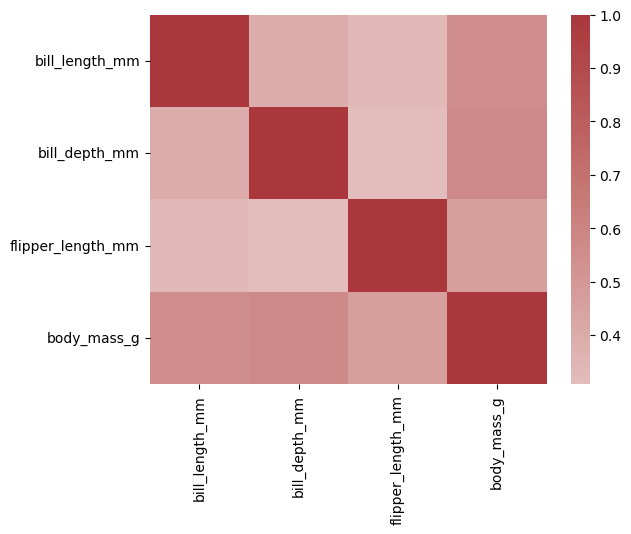

In [16]:
sns.heatmap(adelie_corr, center = 0, cmap = sns.color_palette("vlag", as_cmap=True))

Here all the correlations are positive for Adelie penguins.

Continue for the other species! And try some other datasets, too.